In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from itertools import combinations
import community.community_louvain as community_louvain
import re
from wordcloud import WordCloud, STOPWORDS

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
csv_file = '/content/drive/MyDrive/Tesis_Natalia/Manuscrito_1/Articulos_cienciaciudadana.csv'
excel_file = '/content/drive/MyDrive/Tesis_Natalia/Manuscrito_1/WOSCienciaCiudadana.xlsx'


In [5]:
df_csv = pd.read_csv(csv_file)
df_excel = pd.read_excel(excel_file)

print("CSV:", df_csv.shape)
print("Excel:", df_excel.shape)

all_cols = df_csv.columns.union(df_excel.columns)

df_csv = df_csv.reindex(columns=all_cols)
df_excel = df_excel.reindex(columns=all_cols)

df_concat = pd.concat([df_csv, df_excel], ignore_index=True)

df_concat['Title_clean'] = df_concat['Title'].str.strip().str.lower()

duplicates_bool = df_concat.duplicated(subset='Title_clean', keep='first')

df_duplicates = df_concat[duplicates_bool]

df_clean = df_concat.drop_duplicates(subset='Title_clean', keep='first')

df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')

df_clean = df_clean[(df_clean['Year'] >= 2002) & (df_clean['Year'] <= 2026)]

df_clean.to_csv("articulos_concatenados_sin_duplicados.csv", index=False)
df_duplicates.to_csv("articulos_duplicados.csv", index=False)

print("Concatenación y limpieza de duplicados completada.")
print(f"Total artículos finales: {len(df_clean)}")
print(f"Total duplicados encontrados: {len(df_duplicates)}")

CSV: (4697, 33)
Excel: (517, 65)


/tmp/ipykernel_440/2556345419.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')


Concatenación y limpieza de duplicados completada.
Total artículos finales: 4756
Total duplicados encontrados: 439


In [6]:
print("Columnas del DataFrame final:")
print(df_clean.columns.tolist())

Columnas del DataFrame final:
['180 Day Usage Count', 'Abbreviated Source Title', 'Abstract', 'Addresses', 'Affiliations', 'Art. No.', 'Article Number', 'Author Full Names', 'Author Keywords', 'Author full names', 'Author(s) ID', 'Authors', 'Authors with affiliations', 'Book DOI', 'Book Series Title', 'CODEN', 'Cited Reference Count', 'Cited by', 'Conference Date', 'Conference Location', 'Conference Sponsor', 'Conference Title', 'Correspondence Address', 'DOI', 'DOI Link', 'Date of Export', 'Document Type', 'EID', 'Early Access Date', 'Editors', 'Email Addresses', 'End Page', 'Funding Name Preferred', 'Funding Orgs', 'Funding Text', 'Group Authors', 'Highly Cited Status', 'Hot Paper Status', 'IDS Number', 'ISBN', 'ISSN', 'Index Keywords', 'Issue', 'Journal Abbreviation', 'Journal ISO Abbreviation', 'Keywords Plus', 'Language', 'Language of Original Document', 'Link', 'Meeting Abstract', 'Number of Pages', 'ORCIDs', 'Open Access', 'Open Access Designations', 'Page end', 'Page start', 'P

In [7]:
data = df_clean

Econtrar datos clave que se encuentran en el abstract

In [8]:
print(data['Year'].min())
print(data['Year'].max())

2002
2026


In [ ]:
#df_first_country = df_phyto_unique.groupby('Title').first().reset_index()

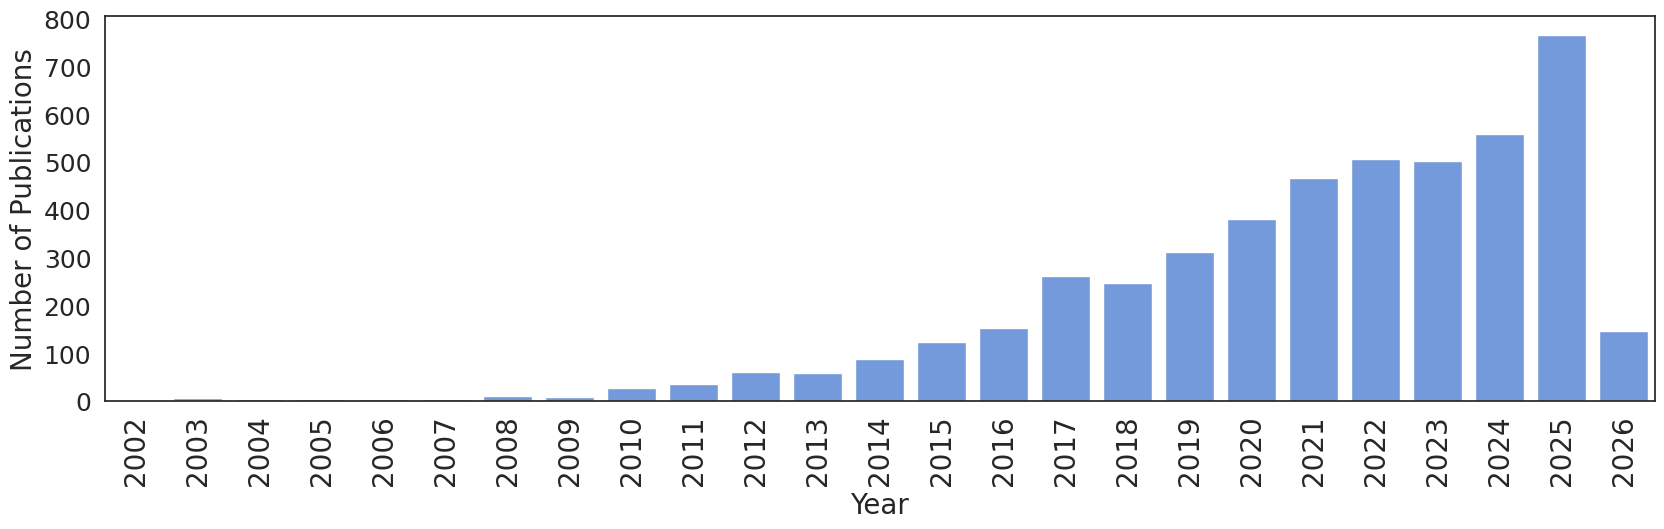

In [9]:
all_years = pd.DataFrame({'Year': range(2002, 2026)})
all_years['Year'] = all_years['Year'].astype(int)
años = data['Year']
años = años.dropna()
publication_counts = años.value_counts().reset_index()
publication_counts.columns = ['Year', 'count']
all_years['Year'] = all_years['Year'].astype(str)
publication_counts = publication_counts[publication_counts['Year']!='0']
all_years = all_years.astype(int)
publication_counts = publication_counts.astype(int)

full_data = pd.merge(all_years, publication_counts, on='Year', how='outer')
full_data = full_data.fillna(0)

full_data['count'] = full_data['count'].astype(int)
full_data['Year'] = full_data['Year'].astype(int)
full_data = full_data.sort_values(by='Year',ascending=True)
full_data = full_data[full_data['Year']>=2002]
sns.set_theme(style='white')
plt.figure(figsize=(20, 5))
sns.barplot(data=full_data, x='Year', y='count',color='cornflowerblue')
plt.xticks(rotation=90, fontsize=20)
plt.yticks( fontsize=18)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of Publications', fontsize=20)
plt.show()

REVISION POR TEMATICA

Macrogrupos

In [10]:
data_macrogrupos = data.copy()

In [11]:
data

,180 Day Usage Count,Abbreviated Source Title,Abstract,Addresses,Affiliations,Art. No.,Article Number,Author Full Names,Author Keywords,Author full names,...,"Times Cited, WoS Core",Title,UT (Unique WOS ID),Volume,Web of Science Index,Web of Science Record,WoS Categories,Year,eISSN,Title_clean
0,NaN,Ornithol. Appl.,Targeted monitoring by trained professionals h...,NaN,"Cornell Lab of Ornithology, Cornell University...",duaf030,NaN,NaN,Anatidae; community science; conservation plan...,"Masto, Nicholas M. (57201557607); Dunham, Kyle...",...,NaN,Citizen science generates reliable migration c...,NaN,127,NaN,NaN,NaN,2025,NaN,citizen science generates reliable migration c...
1,NaN,npj Clim. Atmos. Sci.,Low-cost air quality sensors (LCS) are increas...,NaN,"Environmental Informatics Research Group, Scho...",335,NaN,NaN,NaN,"Bagkis, Evangelos (57222062259); Hassani, Amir...",...,NaN,Evolving trends in application of low-cost air...,NaN,8,NaN,NaN,NaN,2025,NaN,evolving trends in application of low-cost air...
2,NaN,Ecosphere,A shifting climate poses threats to alpine-ada...,NaN,"U.S. Geological Survey, Northern Rocky Mountai...",e70465,NaN,NaN,citizen science; climate; conservation concern...,"Graves, Tabitha A. (15070079700); Janousek, Wi...",...,NaN,"Mountain goat declines in a protected, interio...",NaN,17,NaN,NaN,NaN,2026,NaN,"mountain goat declines in a protected, interio..."
3,NaN,Ocean Coast. Manage.,"The North Yellow Sea, once a vital habitat for...",NaN,"Yellow Sea Fisheries Research Institute, Chine...",107897,NaN,NaN,Cetacean decline; Citizen science; Fishing act...,"Cheng, Zhaolong (56717068800); Li, Yongtao (57...",...,NaN,Collapse of cetacean biodiversity in the North...,NaN,270,NaN,NaN,NaN,2025,NaN,collapse of cetacean biodiversity in the north...
4,NaN,Ecology and Evolution,Biodiversity monitoring at large spatial and t...,NaN,"Office Français de la Biodiversité, Tour du Va...",e72902,NaN,NaN,biodiversity monitoring; imputation; Internati...,"Godeau, U. (57215833580); Gaget, E. (571962776...",...,NaN,Recommendations for Improving the Modeling of ...,NaN,16,NaN,NaN,NaN,2026,NaN,recommendations for improving the modeling of ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,5.0,NaN,The accurate characterization of species diver...,"[Pavon-Vazquez, Carlos J.] Univ Nacl Autonoma ...",Universidad Nacional Autonoma de Mexico; Austr...,NaN,NaN,"Pavon-Vazquez, Carlos J.; Fitch, Alison J.; Do...",Australia; coloration; citizen science; machin...,NaN,...,1.0,"Integrating Genomics, Collections, and Communi...",WOS:001611185500001,NaN,Science Citation Index Expanded (SCI-EXPANDED),View Full Record in Web of Science,Evolutionary Biology,2025,1076-836X,"integrating genomics, collections, and communi..."
5198,2.0,NaN,Essential ecosystem services are provided by m...,"[Handler, Sage; Raine, Nigel E.] Univ Guelph, ...",University of Guelph; Wilfrid Laurier Universi...,NaN,NaN,"Handler, Sage; Coveny, Katerina; Braukmann, Th...",Land use; pollination; range expansion; urban ...,NaN,...,0.0,Welcome to Hotel Hymenoptera: monitoring cavit...,WOS:001684293200001,10,Emerging Sources Citation Index (ESCI),View Full Record in Web of Science,Biochemical Research Methods; Biochemistry & M...,2026,2534-9708,welcome to hotel hymenoptera: monitoring cavit...
5199,0.0,NaN,. Documenting the breeding habitat and distrib...,"[Walker, Brett L.] Colorado Pk & Wildlife, Den...",Iowa State University; Cleveland Museum of Nat...,NaN,10,"Walker, Brett L.; Yappert, Aaron A.; Brennan, ...",krummholz; migratory songbird; sagebrush; Spiz...,NaN,...,2.0,Field research guided by citizen science and m...,WOS:001198221300001,19,Science Citation Index Expanded (SCI-EXPANDED),View Full Record in Web of Science,Biodiversity Conservation; Ecology; Ornithology,2024,NaN,field research guided by citizen science and m...
5205,0.0,NaN,Monitoring is critical for effective groundwat...,"[Jamieson, Michael; Elson, Mabbie; Carruthers,..

In [12]:
data_macrogrupos['text'] = (
    data_macrogrupos['Title'].fillna('') + ' ' +
    data_macrogrupos['Abstract'].fillna('') + ' ' +
    data_macrogrupos['Author Keywords'].fillna('') + ' ' +
    data_macrogrupos['Index Keywords'].fillna('')
).str.lower()

In [13]:
#PLANTAS
data_macrogrupos['plant_context'] = data_macrogrupos['text'].str.contains(
     r'plant disease|crop disease|plant pest|crop pest|plant pathogen|phytopathology|phytosanitary|weed|weeds|invasive weed',
    regex=True,
    case=False
)

# FITOEPIDEMIOLOGÍA
data_macrogrupos['phytoepidemiology_context'] = data_macrogrupos['text'].str.contains(
    r'plant epidemiology|phytoepidemiology|plant disease epidemiology|plant disease spread|crop disease spread|plant disease dynamics|crop disease dynamics|plant epidemic model|crop epidemic model|plant epidemiological model|crop epidemiological model|pathogen spread in plants',
    regex=True,
    case=False
)
#HUMANA
data_macrogrupos['human_context'] = data_macrogrupos['text'].str.contains(
    r'human|patient|clinical|medicine|medical|public health|'
    r'epidemiology of humans|human disease|human infectious disease|'
    r'hospital|healthcare|'
    r'covid|sars-cov-2|influenza|malaria|dengue|zika|ebola|tuberculosis|hiv|aids|'
    r'outbreak investigation|disease surveillance in humans',
    regex=True,
    case=False
)
#ANIMALES
data_macrogrupos['animal_context'] = data_macrogrupos['text'].str.contains(
    r'animal disease|animal health|veterinary|veterinary epidemiology|'
    r'wildlife disease|wildlife health|'
    r'zoonotic|zoonosis|'
    r'avian influenza|foot and mouth disease|african swine fever|'
    r'bovine tuberculosis|rabies',
    regex=True,
    case=False
)
#BIODIVERSIDAD
data_macrogrupos['biodiversity_context'] = data_macrogrupos['text'].str.contains(
    r'wildlife|biodiversity|species|conservation|ecosystem|habitat|bird|mammal|fish|amphibian|invasive|flora|vegetation|plant diversity|forest',
    regex=True,
    case=False
)
#AMBIENTAL
data_macrogrupos['environmental_context'] = data_macrogrupos['text'].str.contains(
    r'environment|environmental|pollution|air quality|water quality|climate|climate change|urban environment|soil|air monitoring|water monitoring|environmental monitoring',
    regex=True,
    case=False
)
#VIGILANCIA FITOSANITARIA
data_macrogrupos['phytosanitary_surveillance'] = data_macrogrupos['text'].str.contains(
    r'plant disease surveillance|crop disease surveillance|plant health surveillance|phytosanitary surveillance|pest surveillance|crop pest monitoring|plant pest monitoring|plant health monitoring|phytosanitary monitoring',
    regex=True,
    case=False
)

In [14]:
data_macrogrupos['pathogen_terms'] = data_macrogrupos['text'].str.contains(
    r'bacteria|fungi|fungus|virus|pathogen|microbial|infection|aphid|beetle|locust|nematode',
    regex=True
)

In [15]:
#Fitopatología
data_macrogrupos['plant_pathology'] = (
    data_macrogrupos['plant_context'] & data_macrogrupos['pathogen_terms']
)
# FITOEPIDEMIOLOGÍA
data_macrogrupos['phytoepidemiology'] = (
    data_macrogrupos['phytoepidemiology_context'] & data_macrogrupos['pathogen_terms']
)

#Epidemiología humana
data_macrogrupos['human_epidemiology'] = (
    data_macrogrupos['human_context'] & data_macrogrupos['pathogen_terms']
)
#Epidemiología Animal
data_macrogrupos['animal_epidemiology'] = (
    data_macrogrupos['animal_context'] & data_macrogrupos['pathogen_terms']
)

# Enfermedades de fauna
data_macrogrupos['Biodiversity'] = (
    data_macrogrupos['biodiversity_context'] & data_macrogrupos['pathogen_terms']
)
# Ambiental
data_macrogrupos['enviromental_disease'] = (
    data_macrogrupos['environmental_context'] & data_macrogrupos['pathogen_terms']
)
# VIGILANCIA fITOSANITARIA
data_macrogrupos['Phytosanitary surveillance'] = (
    data_macrogrupos['phytosanitary_surveillance'] & data_macrogrupos['pathogen_terms']
)

In [16]:
def classify_area(row):

    if row['phytosanitary_surveillance']:
        return 'Phytosanitary Surveillance'

    elif row['phytoepidemiology_context']:
        return 'Phytoepidemiology'

    elif row['plant_context']:
        return 'Plant science'

    elif row['human_context']:
        return 'Human health'

    elif row['biodiversity_context']:
        return 'Biodiversity'

    elif row['environmental_context']:
        return 'Environmental'

    elif row['pathogen_terms']:
        return 'Microbiology'


    else:
        return 'Other'

data_macrogrupos['area'] = data_macrogrupos.apply(classify_area, axis=1)

In [17]:
counts1 = data_macrogrupos.groupby(['Year', 'area']).size().reset_index(name='count')

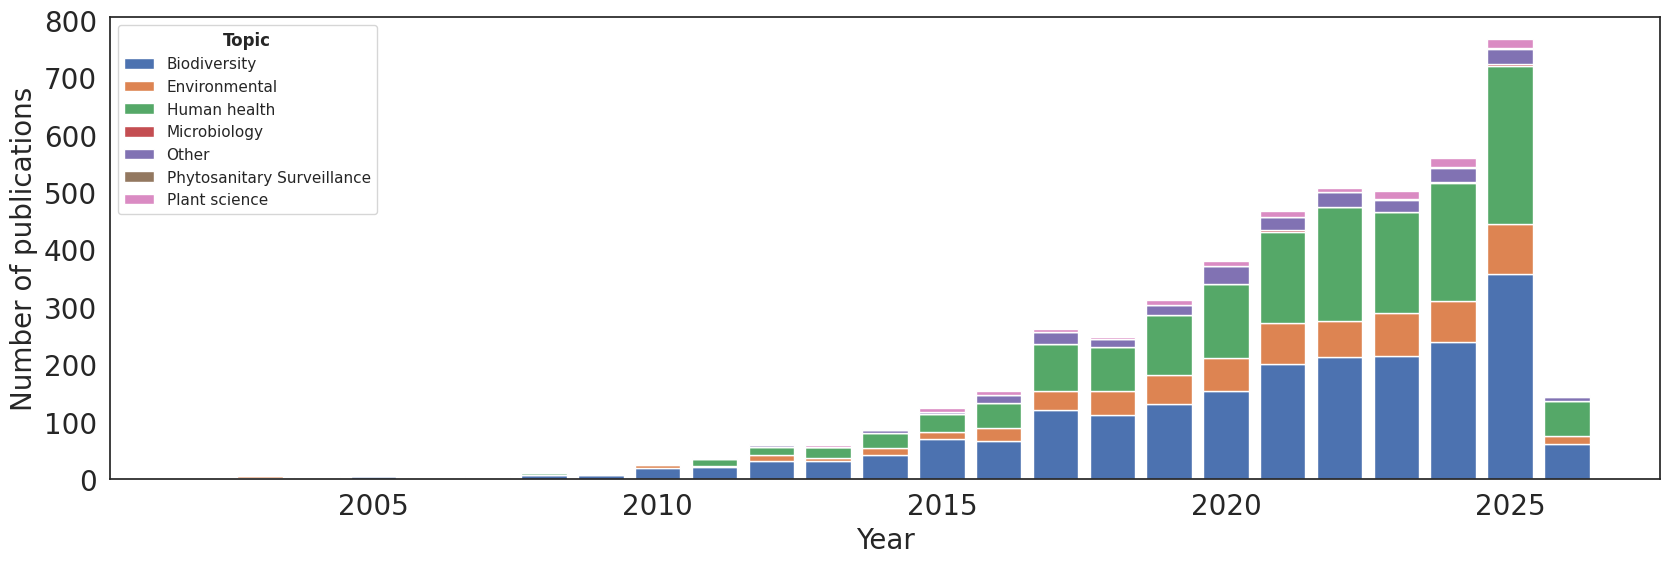

In [18]:
pivot_counts1 = counts1.pivot(index='Year', columns='area', values='count').fillna(0)
pivot_counts1 = pivot_counts1.sort_index()
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(20,6))

bottom = pd.Series([0]*len(pivot_counts1), index=pivot_counts1.index)

for grupo in pivot_counts1.columns:

    plt.bar(
        pivot_counts1.index,
        pivot_counts1[grupo],
        bottom=bottom,
        label=grupo
    )

    bottom += pivot_counts1[grupo]
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of publications', fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

leg = plt.legend(title='Topic')
leg.get_title().set_fontweight('bold')

plt.show()

In [19]:
#Quitar duplicidad de papers en varias areas
def classify_area(row):

    if row['phytosanitary_surveillance']:
        return 'Phytosanitary Surveillance'

    elif row['phytoepidemiology_context']:
        return 'Phytoepidemiology'

data_macrogrupos['area2'] = data_macrogrupos.apply(classify_area, axis=1)


In [20]:
counts2 = data_macrogrupos.groupby(['Year', 'area2']).size().reset_index(name='count')

In [26]:
counts2

,Year,area2,count
0,2016,Phytosanitary Surveillance,1
1,2021,Phytosanitary Surveillance,1
2,2023,Phytosanitary Surveillance,2
3,2024,Phytosanitary Surveillance,1
4,2025,Phytosanitary Surveillance,1
5,2026,Phytosanitary Surveillance,1


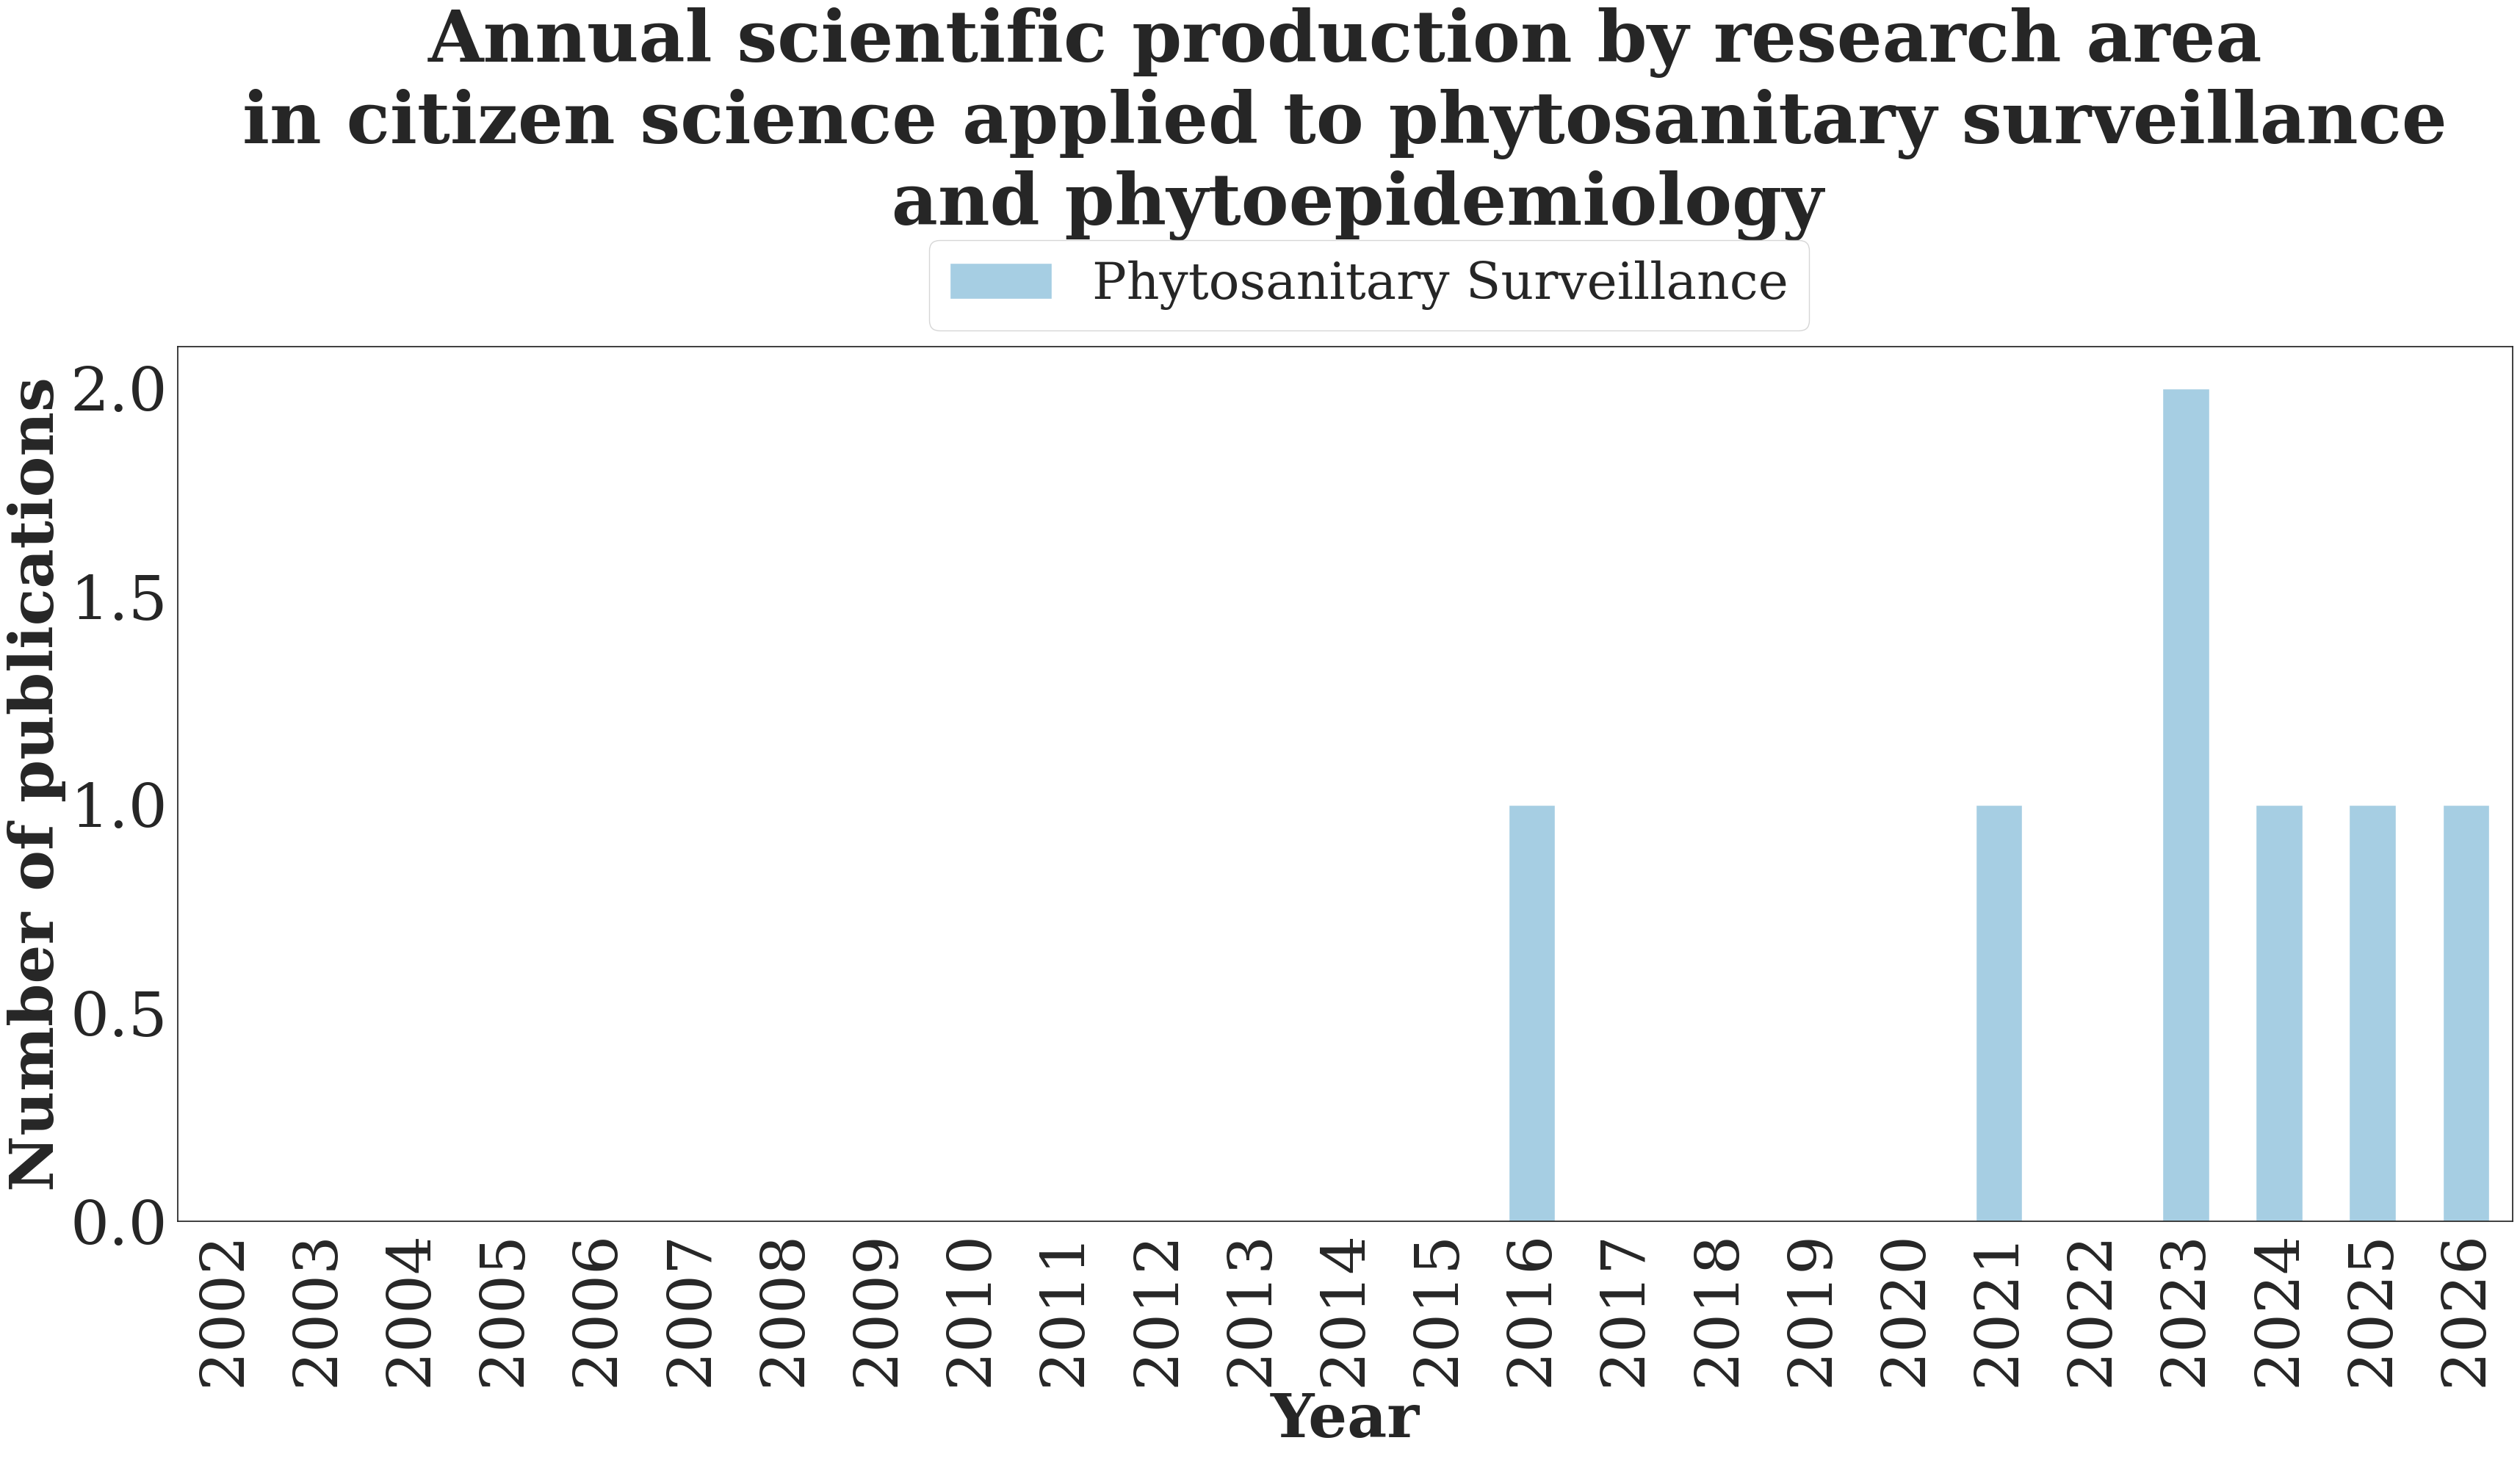

In [27]:
counts2 = counts2[counts2['area2'].notna()]
# CREAR TODOS LOS AÑOS
all_years = pd.DataFrame({'Year': range(2002, 2027)})

# UNIR CON LOS DATOS
counts2_full = pd.merge(all_years, counts2, on='Year', how='left')

# RELLENAR VACIOS CON 0
counts2_full['count'] = counts2_full['count'].fillna(0)

# HACER PIVOT
pivot_counts2 = counts2_full.pivot(index='Year', columns='area2', values='count').fillna(0)
pivot_counts2 = pivot_counts2.sort_index()

pivot_counts2 = pivot_counts2.drop(columns=[None], errors='ignore')
pivot_counts2 = pivot_counts2.drop(columns=[float('nan')], errors='ignore')

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Serif'

fig, ax = plt.subplots(figsize=(35,20))

bottom = pd.Series([0]*len(pivot_counts2), index=pivot_counts2.index)
colors = plt.get_cmap('Paired').colors

# BARRAS APILADAS
for i, grupo in enumerate(pivot_counts2.columns):

    ax.bar(
    pivot_counts2.index,
    pivot_counts2[grupo],
    bottom=bottom,
    label=grupo,
    color=colors[i % len(colors)],
    width=0.5
)

    bottom += pivot_counts2[grupo]

# TITULO
plt.title(
    'Annual scientific production by research area\nin citizen science applied to phytosanitary surveillance\n and phytoepidemiology',
    fontsize=70,
    fontweight='bold',
    pad=120
)

# EJES
ax.set_xlabel('Year', fontsize=60, fontweight='bold')
ax.set_ylabel('Number of publications', fontsize=60, fontweight='bold')
ax.set_xticks(pivot_counts2.index)
ax.tick_params(axis='x', rotation=90, labelsize=60)
ax.tick_params(axis='y', labelsize=60)

ax.set_xlim(
    pivot_counts2.index.min()-0.5,
    pivot_counts2.index.max()+0.5
)

# LIMITES
plt.xlim(
    pivot_counts2.index.min()-0.5,
    pivot_counts2.index.max()+0.5
)
# LEYENDA FUERA DEL GRAFICO
fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.55,0.85),
    fontsize=50,
    ncol=2
)
plt.tight_layout()
plt.show()

In [21]:
duplicados = data_macrogrupos[
    (data_macrogrupos['phytosanitary_surveillance']) &
    (data_macrogrupos['phytoepidemiology_context'])
]

print(duplicados['Title'])

Series([], Name: Title, dtype: object)


In [ ]:
print(data_macrogrupos['phytosanitary_surveillance'].sum())
print(data_macrogrupos['phytoepidemiology_context'].sum())

In [ ]:
(
data_macrogrupos['phytosanitary_surveillance'] &
data_macrogrupos['phytoepidemiology_context']
).sum()

In [ ]:
data_macrogrupos.loc[
    data_macrogrupos['phytoepidemiology_context'],
    'Title'
]

ANALISIS CON DATOS NORMALIZADOS

citizencience topic research asociate to citizen science

In [ ]:
pivot_counts1 = counts1.pivot(index='Year', columns='area', values='count').fillna(0)
pivot_counts1 = pivot_counts1.sort_index()

pivot_counts1 = pivot_counts1[pivot_counts1.index >=2002]
# CREAR SECUENCIA COMPLETA DE AÑOS
all_years = range(pivot_counts1.index.min(), pivot_counts1.index.max() + 1)
pivot_counts1 = pivot_counts1.reindex(all_years, fill_value=0)

# NORMALIZACION A PORCENTAJE
plt.rcParams['font.family'] = 'DejaVu Serif'
pivot_normalizado = pivot_counts1.div(pivot_counts1.sum(axis=1).replace(0,1), axis=0
) * 100

plt.figure(figsize=(35,20))

bottom = pd.Series([0]*len(pivot_normalizado), index=pivot_normalizado.index)

colors = plt.get_cmap('Paired').colors

pivot_normalizado = pivot_normalizado[
    pivot_normalizado.sum().sort_values(ascending=False).index
]

for i, grupo in enumerate(pivot_normalizado.columns):

    plt.bar(
        pivot_normalizado.index,
        pivot_normalizado[grupo],
        bottom=bottom,
        label=grupo,
        color=colors[i % len(colors)],   # aplicar colores pastel
        width = 0.5
    )

    bottom += pivot_normalizado[grupo]

plt.xlabel('Year', fontsize=50, fontweight='bold')
plt.ylabel('Percentage of publications', fontsize=50, fontweight='bold')

plt.xticks(pivot_normalizado.index, rotation=90, fontsize=50)
plt.yticks(fontsize=50)

plt.xlim(
    pivot_normalizado.index.min()-0.5,
    pivot_normalizado.index.max()+0.5
)

# LEYENDA FUERA DEL GRAFICO
leg = plt.legend(
    title='Annual percentage of production in citizen science',
    bbox_to_anchor=(0.01,1.08),
    loc='lower left',
    fontsize=50,
    ncol=3
)

leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(60)

plt.tight_layout()
plt.show()

PAISES APORTANTES

In [ ]:
data['Affiliations_list'] = data['Affiliations'].str.split(';')

In [ ]:
data_expanded = data.explode('Affiliations_list')

In [ ]:
data_expanded['country'] = data_expanded['Affiliations_list'].str.extract(r',\s*([^,]+)$')

In [ ]:
country_counts = data_expanded['country'].value_counts().reset_index()
country_counts.columns = ['country','count']

In [ ]:
print(country_counts.head(70))

In [ ]:
country_counts["count"] = pd.to_numeric(country_counts["count"])

In [ ]:
!pip install pycountry

In [ ]:
import numpy as np
import plotly.express as px
import pycountry

def get_iso3(name):
    manual = {
        "United States": "USA", "USA": "USA", "US": "USA",
        "UK": "GBR", "United Kingdom": "GBR", "England": "GBR",
        "Russia": "RUS", "South Korea": "KOR", "North Korea": "PRK",
        "Iran": "IRN", "Syria": "SYR", "Venezuela": "VEN",
        "Bolivia": "BOL", "Tanzania": "TZA", "Czech Republic": "CZE",
        "Slovakia": "SVK", "Moldova": "MDA", "North Macedonia": "MKD",
        "Democratic Republic Congo": "COD", "DR Congo": "COD",
        "Republic of the Congo": "COG", "Congo": "COG",
        "Ivory Coast": "CIV", "Cote d'Ivoire": "CIV", "Côte d'Ivoire": "CIV",
        "Burma": "MMR", "Myanmar": "MMR", "Taiwan": "TWN",
        "Palestine": "PSE", "Swaziland": "SWZ", "Eswatini": "SWZ",
        "Turkey": "TUR", "Türkiye": "TUR", "Cape Verde": "CPV",
        "Cabo Verde": "CPV", "Falkland Islands": "FLK",
        "Virgin Islands (British)": "VGB",
        "United States of America": "USA",
    }
    if name in manual:
        return manual[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

# Convertir y limpiar
country_counts["iso3"] = country_counts["country"].apply(get_iso3)
df_plot = country_counts[country_counts["iso3"].notna()].copy()

# ✅ Agrupar por iso3 para evitar duplicados (ej. USA aparece dos veces)
df_plot_grouped = df_plot.groupby("iso3", as_index=False).agg(
    count=("count", "sum"),
    country=("country", "first")  # nombre representativo para el hover
)

# Graficar con ISO-3
fig = px.choropleth(
    df_plot_grouped,
    locations="iso3",
    locationmode="ISO-3",
    color="count",
    color_continuous_scale="YlOrRd",
    hover_name="country",
    hover_data={"count": True, "iso3": False},
    title="<b>Global distribution of scientific <br> production in citizen science</b>"

)
fig.update_layout(
    title_x=0.5
)
fig.update_layout(
    title_x=0.5,
    title_y=0.95,
    width=1200,
    height=700,
    font=dict(
        family="DejaVu Sans",
        size=30,
        color="black",

),
coloraxis_colorbar=dict(
        x=1.00
)
)

fig.show()

Co-word analysis - Red de co- ocurrencia (Modificación del codigo)

GRAFICO, ESPECIFICO DE VIGILANCIA FITOSANITARIA Y FITOEPIDEMIOLOGIA

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import pycountry

def get_iso3(name):
    manual = {
        "United States": "USA", "USA": "USA", "US": "USA",
        "UK": "GBR", "United Kingdom": "GBR", "England": "GBR",
        "Russia": "RUS", "South Korea": "KOR", "North Korea": "PRK",
        "Iran": "IRN", "Syria": "SYR", "Venezuela": "VEN",
        "Bolivia": "BOL", "Tanzania": "TZA", "Czech Republic": "CZE",
        "Slovakia": "SVK", "Moldova": "MDA", "North Macedonia": "MKD",
        "Democratic Republic Congo": "COD", "DR Congo": "COD",
        "Republic of the Congo": "COG", "Congo": "COG",
        "Ivory Coast": "CIV", "Cote d'Ivoire": "CIV", "Côte d'Ivoire": "CIV",
        "Burma": "MMR", "Myanmar": "MMR", "Taiwan": "TWN",
        "Palestine": "PSE", "Swaziland": "SWZ", "Eswatini": "SWZ",
        "Turkey": "TUR", "Türkiye": "TUR", "Cape Verde": "CPV",
        "Cabo Verde": "CPV", "Falkland Islands": "FLK",
        "Virgin Islands (British)": "VGB",
        "United States of America": "USA",
    }

    if name in manual:
        return manual[name]

    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

In [ ]:
def classify_area(row):

    if row['phytosanitary_surveillance']:
        return 'Phytosanitary Surveillance'

    elif row['phytoepidemiology_context']:
        return 'Phytoepidemiology'

data_macrogrupos['area2'] = data_macrogrupos.apply(classify_area, axis=1)

In [ ]:
df_phyto = data_macrogrupos[
    data_macrogrupos['area2'].isin(
        ['Phytosanitary Surveillance','Phytoepidemiology']
    )
].copy()

In [ ]:
df_phyto['Affiliations_list'] = df_phyto['Affiliations'].str.split(';')

df_phyto = df_phyto.explode('Affiliations_list')

df_phyto['country'] = df_phyto['Affiliations_list'].str.extract(r',\s*([^,]+)$')

In [ ]:
df_phyto_unique = df_phyto[['Title','country']].drop_duplicates()

country_counts_phyto = (
    df_phyto_unique['country']
    .value_counts()
    .rename_axis('country')
    .reset_index(name='count')
)

country_counts_phyto

In [ ]:
df_phyto_unique.groupby('Title')['country'].nunique().sort_values(ascending=False)

In [ ]:
country_counts_phyto["iso3"] = country_counts_phyto["country"].apply(get_iso3)

df_plot_phyto = country_counts_phyto[
    country_counts_phyto["iso3"].notna()
].copy()

In [ ]:
country_counts_phyto["iso3"] = country_counts_phyto["country"].apply(get_iso3)

df_plot_phyto = country_counts_phyto[
    country_counts_phyto["iso3"].notna()
].copy()

Aunque hay 7 publicaciones sobre vigilancia fitosanitaria, hay articulos en los que han participado autores de diferentes nacionalidades

In [ ]:
fig = px.choropleth(
    df_plot_phyto,
    locations="iso3",
    locationmode="ISO-3",
    color="count",
    color_continuous_scale="YlOrRd",
    hover_name="country",
    hover_data={"count": True, "iso3": False},
    title= "<b>Global distribution of publications in citizen science<br> applied to phytosanitary surveillance and phytoepidemiology</b>"
)

fig.update_layout(
    title_x=0.5
)
fig.update_layout(
    title_x=0.5,
    title_y=0.95,
    width=1200,
    height=700,
    font=dict(
        family="DejaVu Sans",
        size=30,
        color="black",

),
coloraxis_colorbar=dict(
        x=1.00,
        dtick=1
)
)

fig.show()

In [ ]:
import matplotlib

abstracts = data['Author Keywords'].dropna().tolist()

def preprocess(text):


    text = re.sub(r'[;:,\.]', '', text)

    words = text.lower().split()

    stopwords = set([
        'de','la','y','el','en','que','for','and','the','of','to','in','on','with',
        'using','use','based','study','analysis','method','approach','results',
        'paper','article','research','data','model','system','framework',
        'application','case','new','different','various'
    ])

    words = [w.strip() for w in words]

    return [w for w in words if w not in stopwords and len(w) > 3]


processed_abstracts = [preprocess(abs) for abs in abstracts]


all_words = [word for doc in processed_abstracts for word in doc]
word_freq = Counter(all_words)


min_freq = 5
processed_abstracts = [
    [w for w in doc if word_freq[w] >= min_freq]
    for doc in processed_abstracts
]


top_words = set([w for w, _ in word_freq.most_common(75)])

processed_abstracts = [
    [w for w in doc if w in top_words]
    for doc in processed_abstracts
]



coocurrences = Counter()

for words in processed_abstracts:
    unique_words = set(words)
    for pair in combinations(unique_words, 2):
        coocurrences[tuple(sorted(pair))] += 1



G = nx.Graph()

for (word1, word2), weight in coocurrences.items():
    if weight >= 8:
        G.add_edge(word1, word2, weight=weight)



partition = community_louvain.best_partition(G, weight='weight')

num_communities = max(partition.values()) + 1
cmap = matplotlib.colormaps.get_cmap('Pastel1')


pos = {}

for community_id in range(num_communities):

    nodes_in_community = [node for node, comm in partition.items() if comm == community_id]

    subgraph = G.subgraph(nodes_in_community)

    pos_subgraph = nx.spring_layout(subgraph, k=0.5, seed=42)

    offset_x = (community_id % 5) * 3
    offset_y = (community_id // 5) * 3

    for node, (x, y) in pos_subgraph.items():
        pos[node] = (x + offset_x, y + offset_y)



plt.figure(figsize=(15,15))



for community_id in range(num_communities):

    nodes_in_community = [node for node, comm in partition.items() if comm == community_id]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes_in_community,
        node_size=[200 + 80*G.degree(n) for n in nodes_in_community],
        node_color=[cmap(community_id)],
        alpha=0.85
    )



edges = G.edges(data=True)

for u, v, d in edges:

    weight = d['weight']

    c1 = partition[u]
    c2 = partition[v]


    edge_color = cmap(c1) if c1 == c2 else '#dddddd'

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        width=weight * 0.2,   # líneas más delgadas
        edge_color=edge_color,
        alpha=0.35            # más transparencia
    )



nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)


plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
nltk.download('stopwords')

# Stopwords español + inglés
stopwords_1 = set(stopwords.words('spanish')).union(set(stopwords.words('english')))

stopwords_1.update([
    'de','la','y','el','en','que','for','and','the','of','to','in','on','with',
    'using','use','based','study','analysis','method','approach','results',
    'paper','article','research','data','model','system','framework',
    'application','case','new','different','various','review', 'little', 'large',
    'policy', 'litter', 'engagement', 'towards', 'change', 'central', 'driven',
    'alien'

])

# TEXTO A ANALIZAR (ejemplo con TITLES)
text = " ".join(data['Title'].dropna().astype(str))

# Generar WordCloud
wordcloud = WordCloud(
    stopwords=stopwords_1,
    width=1600,
    height=800,
    background_color='Black',
    random_state=42,
    colormap='YlOrBr'
).generate(text)

# Mostrar WordCloud
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')


plt.show()

In [ ]:
nltk.download('stopwords')

# Stopwords español + inglés
stopwords_1 = set(stopwords.words('spanish')).union(set(stopwords.words('english')))

stopwords_1.update([
    'de','la','y','el','en','que','for','and','the','of','to','in','on','with',
    'using','use','based','study','analysis','method','approach','results',
    'paper','article','research','data','model','system','framework', 'agenda', 'building', 'alien'

])

# TEXTO A ANALIZAR (ejemplo con TITLES)
text = " ".join(df_phyto['Title'].dropna().astype(str))

# Generar WordCloud
wordcloud = WordCloud(
    stopwords=stopwords_1,
    width=1600,
    height=800,
    background_color='Black',
    random_state=42,
    colormap='YlOrBr'
).generate(text)

# Mostrar WordCloud
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')


plt.show()

EPIDEIMIOLOGIA DIGITAL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
csv_fileED = '/content/drive/MyDrive/Tesis_Natalia/Manuscritos/Articulos_epidemiologiadigital.csv'
excel_fileED = '/content/drive/MyDrive/Tesis_Natalia/Manuscritos/WOSDigitalEpidemiology.xls'


In [ ]:
df_csvED = pd.read_csv(csv_fileED)
df_excelED = pd.read_excel(excel_fileED)

print("CSVED:", df_csvED.shape)
print("ExcelED:", df_excelED.shape)

all_colsED = df_csvED.columns.union(df_excelED.columns)

df_csvED = df_csvED.reindex(columns=all_cols)
df_excelED = df_excelED.reindex(columns=all_cols)

df_concatED = pd.concat([df_csvED, df_excelED], ignore_index=True)

df_concatED['Title_clean'] = df_concatED['Title'].str.strip().str.lower()

duplicates_boolED = df_concatED.duplicated(subset='Title_clean', keep='first')

df_duplicatesED = df_concatED[duplicates_boolED]

df_cleanED = df_concatED.drop_duplicates(subset='Title_clean', keep='first')

df_cleanED.to_csv("articulos_concatenados_sin_duplicados.csv", index=False)
df_duplicatesED.to_csv("articulos_duplicados.csv", index=False)

print("Concatenación y limpieza de duplicados completada.")
print(f"Total artículos finales: {len(df_cleanED)}")
print(f"Total duplicados encontrados: {len(df_duplicatesED)}")

In [ ]:
dataED = df_cleanED

In [ ]:
all_yearsED = pd.DataFrame({'Year': range(2002, 2026)})
all_yearsED['Year'] = all_yearsED['Year'].astype(int)
añosED = dataED['Year']
añosED = añosED.dropna()
publication_countsED = añosED.value_counts().reset_index()
publication_countsED.columns = ['Year', 'count']
all_yearsED['Year'] = all_yearsED['Year'].astype(str)
publication_countsED = publication_countsED[publication_countsED['Year']!='0']
all_yearsED = all_yearsED.astype(int)
publication_countsED = publication_countsED.astype(int)

full_dataED = pd.merge(all_yearsED, publication_countsED, on='Year', how='outer')
full_dataED = full_dataED.fillna(0)

full_dataED['count'] = full_dataED['count'].astype(int)
full_dataED['Year'] = full_dataED['Year'].astype(int)
full_dataED = full_dataED.sort_values(by='Year',ascending=True)
full_dataED = full_dataED[full_dataED['Year']>=2000]
sns.set_theme(style='white')
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.figure(figsize=(20, 5))
sns.barplot(data=full_dataED, x='Year', y='count',color='seagreen')
plt.xticks(rotation=90, fontsize=20)
plt.yticks( fontsize=18)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of Publications', fontsize=20)

plt.show()

In [ ]:
data_macrogruposED = dataED.copy()

In [ ]:
data_macrogruposED['text'] = (
    data_macrogruposED['Title'].fillna('') + ' ' +
    data_macrogruposED['Abstract'].fillna('') + ' ' +
    data_macrogruposED['Author Keywords'].fillna('') + ' ' +
    data_macrogruposED['Index Keywords'].fillna('')
).str.lower()

In [ ]:
#PLANTAS
data_macrogruposED['plant_contextED'] = data_macrogruposED['text'].str.contains(
     r'plant disease|crop disease|plant pest|crop pest|plant pathogen|phytopathology|phytosanitary|weed|weeds|invasive weed',
    regex=True,
    case=False
)

# FITOEPIDEMIOLOGÍA
data_macrogruposED['phytoepidemiology_contextED'] = data_macrogruposED['text'].str.contains(
    r'plant epidemiology|phytoepidemiology|plant disease epidemiology|plant disease spread|crop disease spread|plant disease dynamics|crop disease dynamics|plant epidemic model|crop epidemic model|plant epidemiological model|crop epidemiological model|pathogen spread in plants',
    regex=True,
    case=False
)
#HUMANA
data_macrogruposED['human_contextED'] = data_macrogruposED['text'].str.contains(
    r'human|patient|clinical|medicine|medical|public health|'
    r'epidemiology of humans|human disease|human infectious disease|'
    r'hospital|healthcare|'
    r'covid|sars-cov-2|influenza|malaria|dengue|zika|ebola|tuberculosis|hiv|aids|'
    r'outbreak investigation|disease surveillance in humans',
    regex=True,
    case=False
)
#ANIMALES
data_macrogruposED['animal_contextED'] = data_macrogruposED['text'].str.contains(
    r'animal disease|animal health|veterinary|veterinary epidemiology|'
    r'wildlife disease|wildlife health|'
    r'zoonotic|zoonosis|'
    r'avian influenza|foot and mouth disease|african swine fever|'
    r'bovine tuberculosis|rabies',
    regex=True,
    case=False
)
#BIODIVERSIDAD
data_macrogruposED['biodiversity_contextED'] = data_macrogruposED['text'].str.contains(
    r'wildlife|biodiversity|species|conservation|ecosystem|habitat|bird|mammal|fish|amphibian|invasive|flora|vegetation|plant diversity|forest',
    regex=True,
    case=False
)
#AMBIENTAL
data_macrogruposED['environmental_contextED'] = data_macrogruposED['text'].str.contains(
    r'environment|environmental|pollution|air quality|water quality|climate|climate change|urban environment|soil|air monitoring|water monitoring|environmental monitoring',
    regex=True,
    case=False
)
#VIGILANCIA FITOSANITARIA
data_macrogruposED['phytosanitary_surveillanceED'] = data_macrogruposED['text'].str.contains(
    r'plant disease surveillance|crop disease surveillance|plant health surveillance|phytosanitary surveillance|pest surveillance|crop pest monitoring|plant pest monitoring|plant health monitoring|phytosanitary monitoring',
    regex=True,
    case=False
)

In [ ]:
data_macrogruposED['pathogen_termsED'] = data_macrogruposED['text'].str.contains(
    r'bacteria|fungi|fungus|virus|pathogen|microbial|infection|aphid|beetle|locust|nematode',
    regex=True
)

In [ ]:
#Fitopatología
data_macrogruposED['plant_pathologyED'] = (
    data_macrogruposED['plant_contextED'] & data_macrogruposED['pathogen_termsED']
)
# FITOEPIDEMIOLOGÍA
data_macrogruposED['phytoepidemiologyED'] = (
    data_macrogruposED['phytoepidemiology_contextED'] & data_macrogruposED['pathogen_termsED']
)

#Epidemiología humana
data_macrogruposED['human_epidemiologyED'] = (
    data_macrogruposED['human_contextED'] & data_macrogruposED['pathogen_termsED']
)
#Epidemiología Animal
data_macrogruposED['animal_epidemiologyED'] = (
    data_macrogruposED['animal_contextED'] & data_macrogruposED['pathogen_termsED']
)

# Enfermedades de fauna
data_macrogruposED['BiodiversityED'] = (
    data_macrogruposED['biodiversity_contextED'] & data_macrogruposED['pathogen_termsED']
)
# Ambiental
data_macrogruposED['enviromental_diseaseED'] = (
    data_macrogruposED['environmental_contextED'] & data_macrogruposED['pathogen_termsED']
)
# VIGILANCIA fITOSANITARIA
data_macrogruposED['phytosanitary surveillanceED'] = (
    data_macrogruposED['phytosanitary_surveillanceED'] & data_macrogruposED['pathogen_termsED']
)

In [ ]:
def classify_areaED(row):

    if row['phytosanitary_surveillanceED']:
        return 'Phytosanitary Surveillance'

    elif row['phytoepidemiology_contextED']:
        return 'Phytoepidemiology'

    elif row['plant_contextED']:
        return 'Plant scienceED'

    elif row['human_contextED']:
        return 'Human health'

    elif row['biodiversity_contextED']:
        return 'Biodiversity'

    elif row['environmental_contextED']:
        return 'Environmental'

    elif row['pathogen_termsED']:
        return 'Microbiology'


    else:
        return 'Other'

data_macrogruposED['areaED'] = data_macrogruposED.apply(classify_areaED, axis=1)

In [ ]:
countsED = data_macrogruposED.groupby(['Year', 'areaED']).size().reset_index(name='countED')

In [ ]:
pivot_countsED = countsED.pivot(index='Year', columns='areaED', values='countED').fillna(0)
pivot_countsED = pivot_countsED.sort_index()
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(20,6))

bottom = pd.Series([0]*len(pivot_countsED), index=pivot_countsED.index)

for grupo in pivot_countsED.columns:

    plt.bar(
        pivot_countsED.index,
        pivot_countsED[grupo],
        bottom=bottom,
        label=grupo
    )

    bottom += pivot_countsED[grupo]
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of publications', fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

leg = plt.legend(title='Topic')
leg.get_title().set_fontweight('bold')

plt.show()

In [ ]:
print(data_macrogruposED['phytosanitary_surveillanceED'].sum())
print(data_macrogruposED['phytoepidemiology_contextED'].sum())

In [ ]:
counts_phytoED = data_macrogruposED.groupby(['Year', 'areaED']).size().reset_index(name='countED')

In [ ]:
def classify_areaED(row):

    if row['phytosanitary_surveillanceED']:
        return 'Phytosanitary Surveillance'

    elif row['phytoepidemiology_contextED']:
        return 'Phytoepidemiology'

data_macrogruposED['area2ED'] = data_macrogruposED.apply(classify_areaED, axis=1)


In [ ]:
countsED = data_macrogruposED.groupby(['Year', 'area2ED']).size().reset_index(name='countED')

In [ ]:
# FILTRAR SOLO FILAS CON AREA DEFINIDA
countsED = countsED[countsED['area2ED'].notna()]

# CREAR TODOS LOS AÑOS
all_years = pd.DataFrame({'Year': range(2002, 2026)})

# UNIR CON LOS DATOS
counts2_full = pd.merge(all_years, countsED, on='Year', how='left')

# RELLENAR VACÍOS
counts2_full['countED'] = counts2_full['countED'].fillna(0)

# HACER PIVOT
pivot_counts2 = counts2_full.pivot(index='Year', columns='area2ED', values='countED').fillna(0)
pivot_counts2 = pivot_counts2.sort_index()

# ELIMINAR COLUMNAS VACÍAS
pivot_counts2 = pivot_counts2.drop(columns=[None], errors='ignore')
pivot_counts2 = pivot_counts2.drop(columns=[float('nan')], errors='ignore')

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Serif'

fig, ax = plt.subplots(figsize=(35,20))

bottom = pd.Series([0]*len(pivot_counts2), index=pivot_counts2.index)
colors = plt.get_cmap('Paired').colors

# BARRAS APILADAS
for i, grupo in enumerate(pivot_counts2.columns):

    ax.bar(
        pivot_counts2.index,
        pivot_counts2[grupo],
        bottom=bottom,
        label=grupo,
        color=colors[i % len(colors)],
        width=0.5
    )

    bottom += pivot_counts2[grupo]

# TITULO
plt.title(
    'Annual scientific production by research area\nin digital epidemiology applied to phytosanitary surveillance\n and phytoepidemiology',
    fontsize=70,
    fontweight='bold',
    pad=120
)

# EJES
ax.set_xlabel('Year', fontsize=60, fontweight='bold')
ax.set_ylabel('Number of publications', fontsize=60, fontweight='bold')

ax.set_xticks(pivot_counts2.index)
ax.tick_params(axis='x', rotation=90, labelsize=60)
ax.tick_params(axis='y', labelsize=60)

# LIMITES
ax.set_xlim(
    pivot_counts2.index.min()-0.5,
    pivot_counts2.index.max()+0.5
)

# LEYENDA ENTRE TITULO Y GRAFICA
fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.535,0.85),
    fontsize=50,
    ncol=2
)

plt.tight_layout()
plt.show()

ANALISIS CON DATOS NORMALIZADOS DE EPIDEMIOLOGIA DIGITAL

In [ ]:
pivot_countsED = counts_phytoED.pivot(index='Year', columns='areaED', values='countED').fillna(0)
pivot_countsED = pivot_countsED.sort_index()

pivot_countsED.index = pivot_countsED.index.astype(int)
pivot_countsED = pivot_countsED[pivot_countsED.index >=2000]
# CREAR SECUENCIA COMPLETA DE AÑOS
all_years = range(pivot_countsED.index.min(), pivot_countsED.index.max() + 1)
pivot_countsED = pivot_countsED.reindex(all_years, fill_value=0)

# NORMALIZACION A PORCENTAJE
plt.rcParams['font.family'] = 'DejaVu Serif'
pivot_normalizadoED = pivot_countsED.div(pivot_countsED.sum(axis=1).replace(0,1), axis=0
) * 100

plt.figure(figsize=(35,20))

bottom = pd.Series([0]*len(pivot_normalizadoED), index=pivot_normalizadoED.index)

colors = plt.get_cmap('Paired').colors

pivot_normalizadoED = pivot_normalizadoED[
    pivot_normalizadoED.sum().sort_values(ascending=False).index
]

for i, grupo in enumerate(pivot_normalizadoED.columns):

    plt.bar(
        pivot_normalizadoED.index,
        pivot_normalizadoED[grupo],
        bottom=bottom,
        label=grupo,
        color=colors[i % len(colors)],   # aplicar colores pastel
        width = 0.5
    )

    bottom += pivot_normalizadoED[grupo]

plt.xlabel('Year', fontsize=50, fontweight='bold')
plt.ylabel('Percentage of publications', fontsize=50, fontweight='bold')

plt.xticks(pivot_normalizadoED.index, rotation=90, fontsize=50)
plt.yticks(fontsize=50)

plt.xlim(
    pivot_normalizadoED.index.min()-0.5,
    pivot_normalizadoED.index.max()+0.5
)

# LEYENDA FUERA DEL GRAFICO
leg = plt.legend(
    title='Annual percentage of productions in digital epidemiology',
    bbox_to_anchor=(0.01,1.08),
    loc='lower left',
    fontsize=50,
    ncol=3
)

leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(60)

plt.tight_layout()
plt.show()

PAISES APORTANTES DE EPIDEMIOLOGIA DIGITAL

In [ ]:
dataED['Affiliations_list'] = dataED['Affiliations'].str.split(';')

In [ ]:
dataED_expanded = dataED.explode('Affiliations_list')

In [ ]:
dataED_expanded['country'] = dataED_expanded['Affiliations_list'].str.extract(r',\s*([^,]+)$')

In [ ]:
country_countsED = dataED_expanded['country'].value_counts().reset_index()
country_countsED.columns = ['country','count']

In [ ]:
print(country_counts.head(10))

In [ ]:
country_countsED["count"] = pd.to_numeric(country_countsED["count"])

In [ ]:
def get_iso3(name):
    manual = {
        "United States": "USA", "USA": "USA", "US": "USA",
        "UK": "GBR", "United Kingdom": "GBR", "England": "GBR",
        "Russia": "RUS", "South Korea": "KOR", "North Korea": "PRK",
        "Iran": "IRN", "Syria": "SYR", "Venezuela": "VEN",
        "Bolivia": "BOL", "Tanzania": "TZA", "Czech Republic": "CZE",
        "Slovakia": "SVK", "Moldova": "MDA", "North Macedonia": "MKD",
        "Democratic Republic Congo": "COD", "DR Congo": "COD",
        "Republic of the Congo": "COG", "Congo": "COG",
        "Ivory Coast": "CIV", "Cote d'Ivoire": "CIV", "Côte d'Ivoire": "CIV",
        "Burma": "MMR", "Myanmar": "MMR", "Taiwan": "TWN",
        "Palestine": "PSE", "Swaziland": "SWZ", "Eswatini": "SWZ",
        "Turkey": "TUR", "Türkiye": "TUR", "Cape Verde": "CPV",
        "Cabo Verde": "CPV", "Falkland Islands": "FLK",
        "Virgin Islands (British)": "VGB",
        "United States of America": "USA",
    }
    if name in manual:
        return manual[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None


country_countsED["iso3"] = country_countsED["country"].apply(get_iso3)
df_plotED = country_countsED[country_countsED["iso3"].notna()].copy()

# ✅ Agrupar por iso3 para evitar duplicados (ej. USA aparece dos veces)
df_plot_groupedED = (df_plotED.groupby("iso3", as_index=False).agg(
    count=("count", "sum"),
    country=("country", "first")  # nombre representativo para el hover
)
)
# Graficar con ISO-3
fig = px.choropleth(
    df_plot_groupedED,
    locations="iso3",
    locationmode="ISO-3",
    color="count",
    color_continuous_scale="YlOrRd",
    hover_name="country",
    hover_data={"count": True, "iso3": False},
    title="<b>Global distribution of scientific <br> production in digital epidemiology</b>"

)
fig.update_layout(
    title_x=0.5
)
fig.update_layout(
    title_x=0.5,
    title_y=0.95,
    width=1200,
    height=700,
    font=dict(
        family="DejaVu Sans",
        size=30,
        color="black",

),
coloraxis_colorbar=dict(
        x=1.00
)
)

fig.show()

GRAFICO, ESPECIFICO DE VIGILANCIA FITOSANITARIA

In [ ]:
df_phytoED['Affiliations_list'] = df_phytoED['Affiliations'].str.split(';')

df_phytoED = df_phytoED.explode('Affiliations_list')

df_phytoED['country'] = df_phytoED['Affiliations_list'].str.extract(r',\s*([^,]+)$')

In [ ]:
df_phyto_uniqueED = df_phytoED[['Title','country']].drop_duplicates()

country_counts_phytoED = (
    df_phyto_uniqueED['country']
    .value_counts()
    .rename_axis('country')
    .reset_index(name='count')
)

In [ ]:
country_counts_phytoED["iso3"] = country_counts_phytoED["country"].apply(get_iso3)

In [ ]:
df_plot_phytoED = country_counts_phytoED[
    country_counts_phytoED["iso3"].notna()
].copy()

In [ ]:
figED = px.choropleth(
    df_plot_phytoED,
    locations="iso3",
    locationmode="ISO-3",
    color="count",
    color_continuous_scale="YlOrRd",
    range_color=(0,1),
    hover_name="country",
    hover_data={"count": True, "iso3": False},
    title="<b>Global distribution of publications in<br> digital epidemiology applied to phytosanitary surveillance <br>and phytoepidemiology</b>"
)


figED.update_layout(
    title_x=0.5,
    title_y=0.95,
    width=1200,
    height=700,
    font=dict(
        family="DejaVu Sans",
        size=30,
        color="black",

),
coloraxis_colorbar=dict(
        x=1.00,
        dtick=1.00
)
)

figED.show()

In [ ]:
import matplotlib

abstracts = dataED['Author Keywords'].dropna().tolist()

def preprocess(text):


    text = re.sub(r'[;:,\.]', '', text)

    words = text.lower().split()

    stopwords = set([
        'de','la','y','el','en','que','for','and','the','of','to','in','on','with',
        'using','use','based','study','analysis','method','approach','results',
        'paper','article','research','data','model','system','framework',
        'application','case','new','different','various'
    ])

    words = [w.strip() for w in words]

    return [w for w in words if w not in stopwords and len(w) > 3]


processed_abstracts = [preprocess(abs) for abs in abstracts]


all_words = [word for doc in processed_abstracts for word in doc]
word_freq = Counter(all_words)


min_freq = 5
processed_abstracts = [
    [w for w in doc if word_freq[w] >= min_freq]
    for doc in processed_abstracts
]


top_words = set([w for w, _ in word_freq.most_common(100)])

processed_abstracts = [
    [w for w in doc if w in top_words]
    for doc in processed_abstracts
]



coocurrences = Counter()

for words in processed_abstracts:
    unique_words = set(words)
    for pair in combinations(unique_words, 2):
        coocurrences[tuple(sorted(pair))] += 1



G = nx.Graph()

for (word1, word2), weight in coocurrences.items():
    if weight >= 8:
        G.add_edge(word1, word2, weight=weight)



partition = community_louvain.best_partition(G, weight='weight')

num_communities = max(partition.values()) + 1
cmap = matplotlib.colormaps.get_cmap('Pastel1')


pos = {}

for community_id in range(num_communities):

    nodes_in_community = [node for node, comm in partition.items() if comm == community_id]

    subgraph = G.subgraph(nodes_in_community)

    pos_subgraph = nx.spring_layout(subgraph, k=0.5, seed=42)

    offset_x = (community_id % 5) * 3
    offset_y = (community_id // 5) * 3

    for node, (x, y) in pos_subgraph.items():
        pos[node] = (x + offset_x, y + offset_y)



plt.figure(figsize=(15,15))



for community_id in range(num_communities):

    nodes_in_community = [node for node, comm in partition.items() if comm == community_id]

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodes_in_community,
        node_size=[200 + 80*G.degree(n) for n in nodes_in_community],
        node_color=[cmap(community_id)],
        alpha=0.85
    )



edges = G.edges(data=True)

for u, v, d in edges:

    weight = d['weight']

    c1 = partition[u]
    c2 = partition[v]


    edge_color = cmap(c1) if c1 == c2 else '#dddddd'

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        width=weight * 0.2,   # líneas más delgadas
        edge_color=edge_color,
        alpha=0.35            # más transparencia
    )



nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)


plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Librerías necesarias
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')

# Stopwords español + inglés
stopwords_1 = set(stopwords.words('spanish')).union(set(stopwords.words('english')))

stopwords_1.update([
    'de','la','y','el','en','que','for','and','the','of','to','in','on','with',
    'using','use','based','study','analysis','method','approach','results',
    'paper','article','research','data','model','system','framework',
    'application','case','new','different','various'
])

# TEXTO A ANALIZAR (ejemplo con TITLES)
text = " ".join(dataED['Title'].dropna().astype(str))

# Generar WordCloud
wordcloud = WordCloud(
    stopwords=stopwords_1,
    width=1600,
    height=800,
    background_color='Black',
    random_state=42,
    colormap='GnBu_r'
).generate(text)

# Mostrar WordCloud
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')



plt.show()

In [ ]:
nltk.download('stopwords')

# Stopwords español + inglés
stopwords_1 = set(stopwords.words('spanish')).union(set(stopwords.words('english')))

stopwords_1.update([
    'de','la','y','el','en','que','for','and','the','of','to','in','on','with',
    'using','use','based','study','analysis','method','approach','results',
    'paper','article','research','data','model','system','framework', 'agenda', 'building', 'alien'

])

# TEXTO A ANALIZAR (ejemplo con TITLES)
text = " ".join(df_phytoED['Title'].dropna().astype(str))

# Generar WordCloud
wordcloud = WordCloud(
    stopwords=stopwords_1,
    width=1600,
    height=800,
    background_color='Black',
    random_state=42,
    colormap='GnBu_r'
).generate(text)

# Mostrar WordCloud
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')



plt.show()